# Apples Quality

I use the following dataset: https://www.kaggle.com/datasets/nelgiriyewithana/apple-quality/data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('apple_quality.csv')
df.head()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good


## Clean Column

In [3]:
df.drop(columns = ['A_id'], axis = 1, inplace = True)

## EDA

In [4]:
df.isnull().sum()

Size           1
Weight         1
Sweetness      1
Crunchiness    1
Juiciness      1
Ripeness       1
Acidity        0
Quality        1
dtype: int64

In [5]:
df.dropna(axis = 0, inplace = True)

In [6]:
df.isnull().sum()

Size           0
Weight         0
Sweetness      0
Crunchiness    0
Juiciness      0
Ripeness       0
Acidity        0
Quality        0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Size         4000 non-null   float64
 1   Weight       4000 non-null   float64
 2   Sweetness    4000 non-null   float64
 3   Crunchiness  4000 non-null   float64
 4   Juiciness    4000 non-null   float64
 5   Ripeness     4000 non-null   float64
 6   Acidity      4000 non-null   object 
 7   Quality      4000 non-null   object 
dtypes: float64(6), object(2)
memory usage: 281.2+ KB


We can see the 'Acidity' column is a object type, so we gonna fix this

In [8]:
df['Acidity'] = pd.to_numeric(df['Acidity'])
df['Acidity'] = df['Acidity'].astype(float)

In [9]:
df.head()

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590,good
1,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809,good
2,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636,bad
3,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723,good
4,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984,good


In [10]:
df.describe()

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,-0.503015,-0.989547,-0.470479,0.985478,0.512118,0.498277,0.076877
std,1.928059,1.602507,1.943441,1.402757,1.930286,1.874427,2.110270
min,-7.151703,-7.149848,-6.894485,-6.055058,-5.961897,-5.864599,-7.010538
25%,-1.816765,-2.011770,-1.738425,0.062764,-0.801286,-0.771677,-1.377424
50%,-0.513703,-0.984736,-0.504758,0.998249,0.534219,0.503445,0.022609
75%,0.805526,0.030976,0.801922,1.894234,1.835976,1.766212,1.510493
max,6.406367,5.790714,6.374916,7.619852,7.364403,7.237837,7.404736


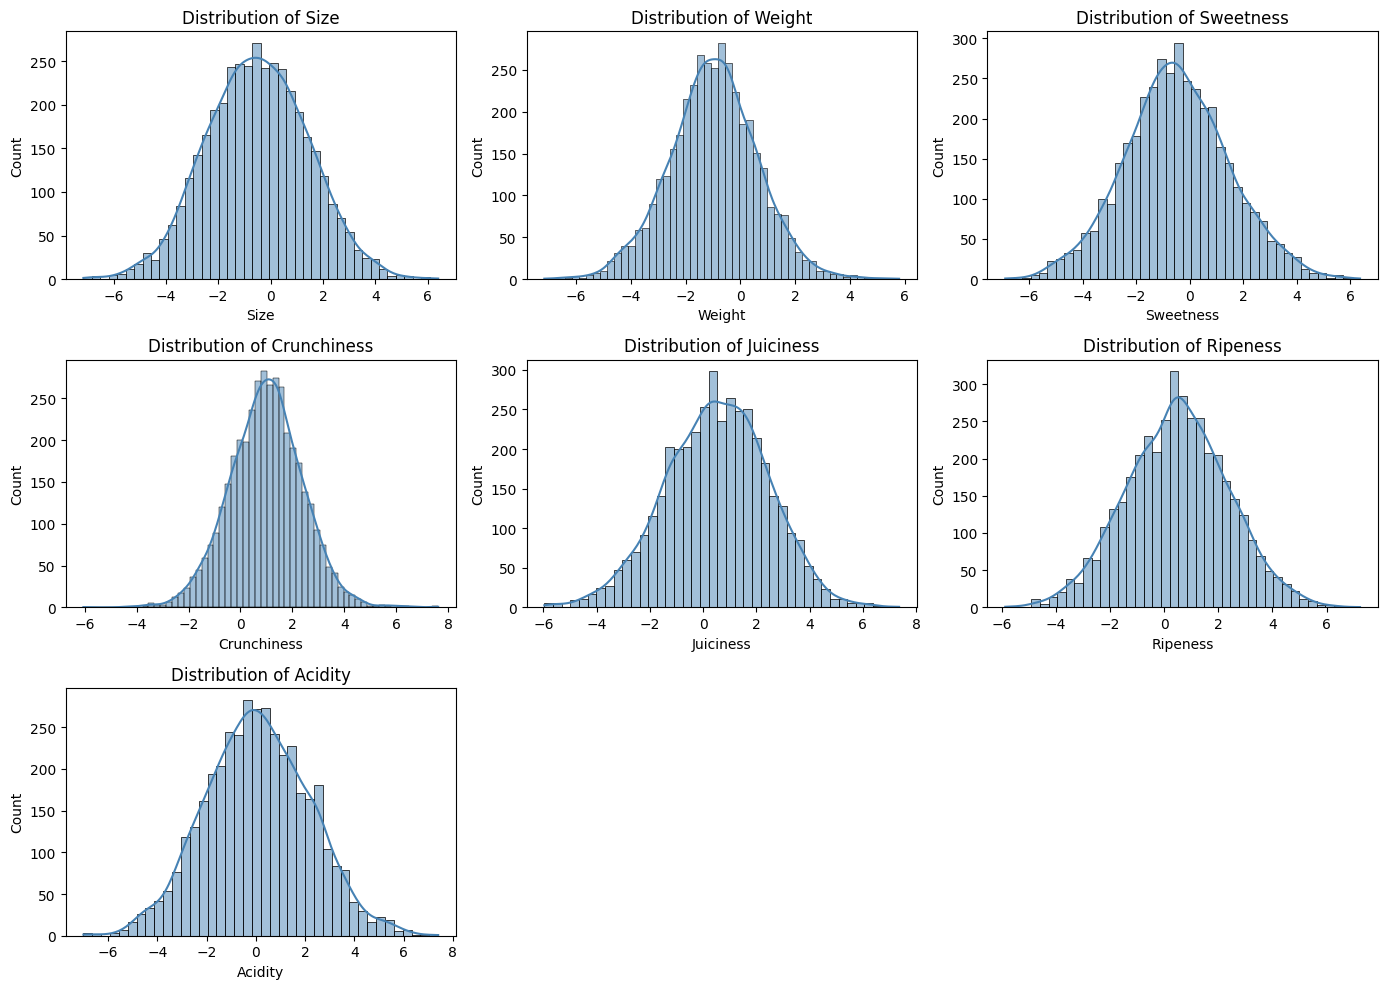

In [11]:
numeric_cols = df.select_dtypes(include = [np.number]).columns

plt.figure(figsize=(14, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True, color='steelblue')
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

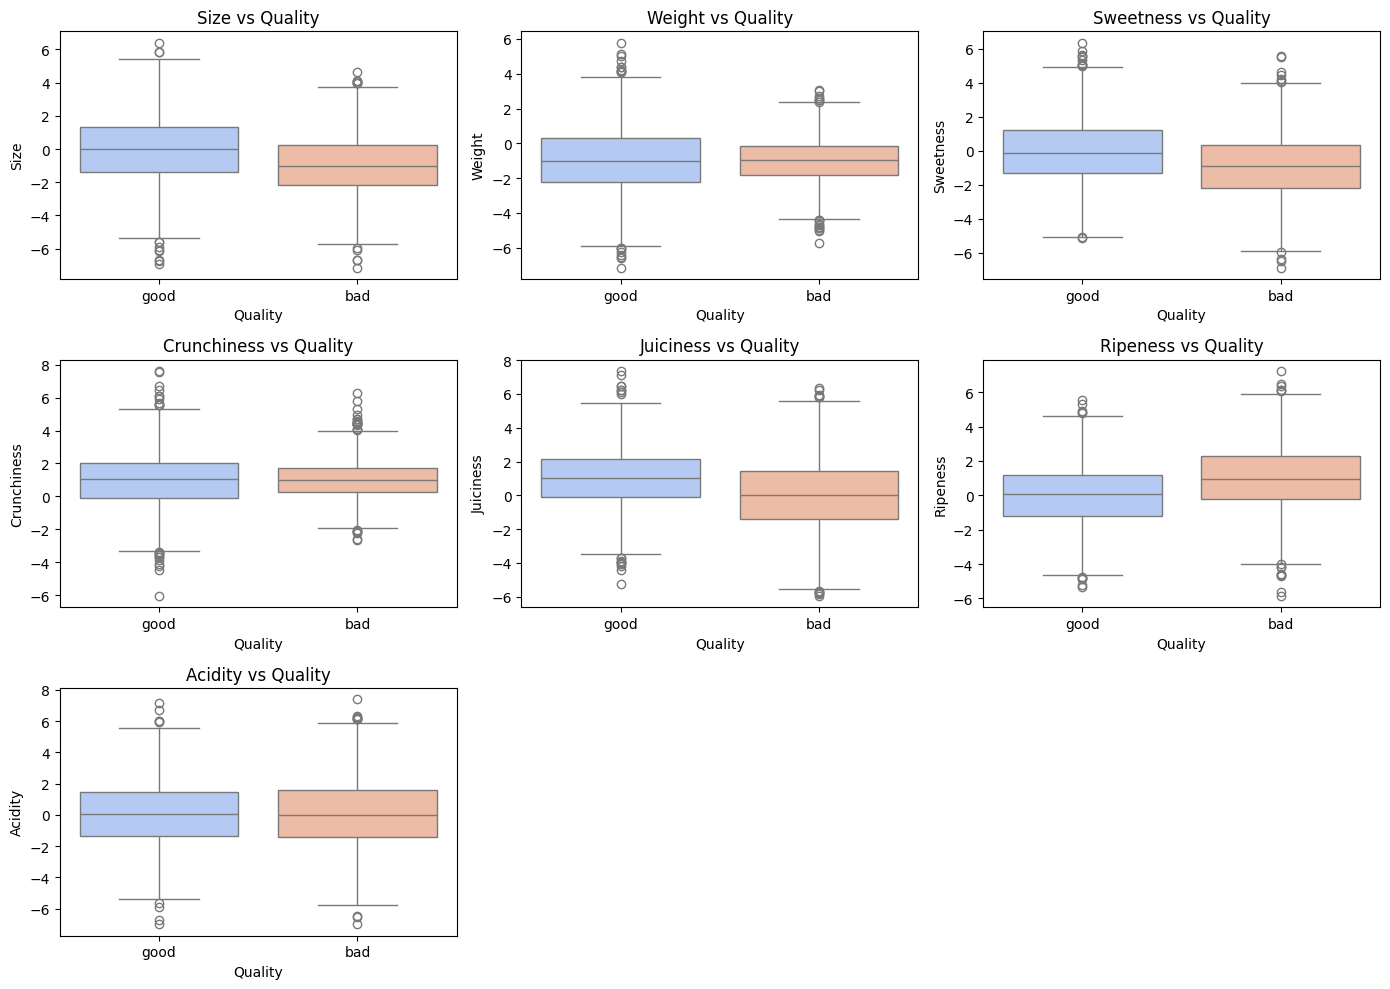

In [12]:
plt.figure(figsize=(14, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(data = df, x = 'Quality', y = col, hue = 'Quality', palette = 'coolwarm', legend = False)
    plt.title(f"{col} vs Quality")
plt.tight_layout()
plt.show()

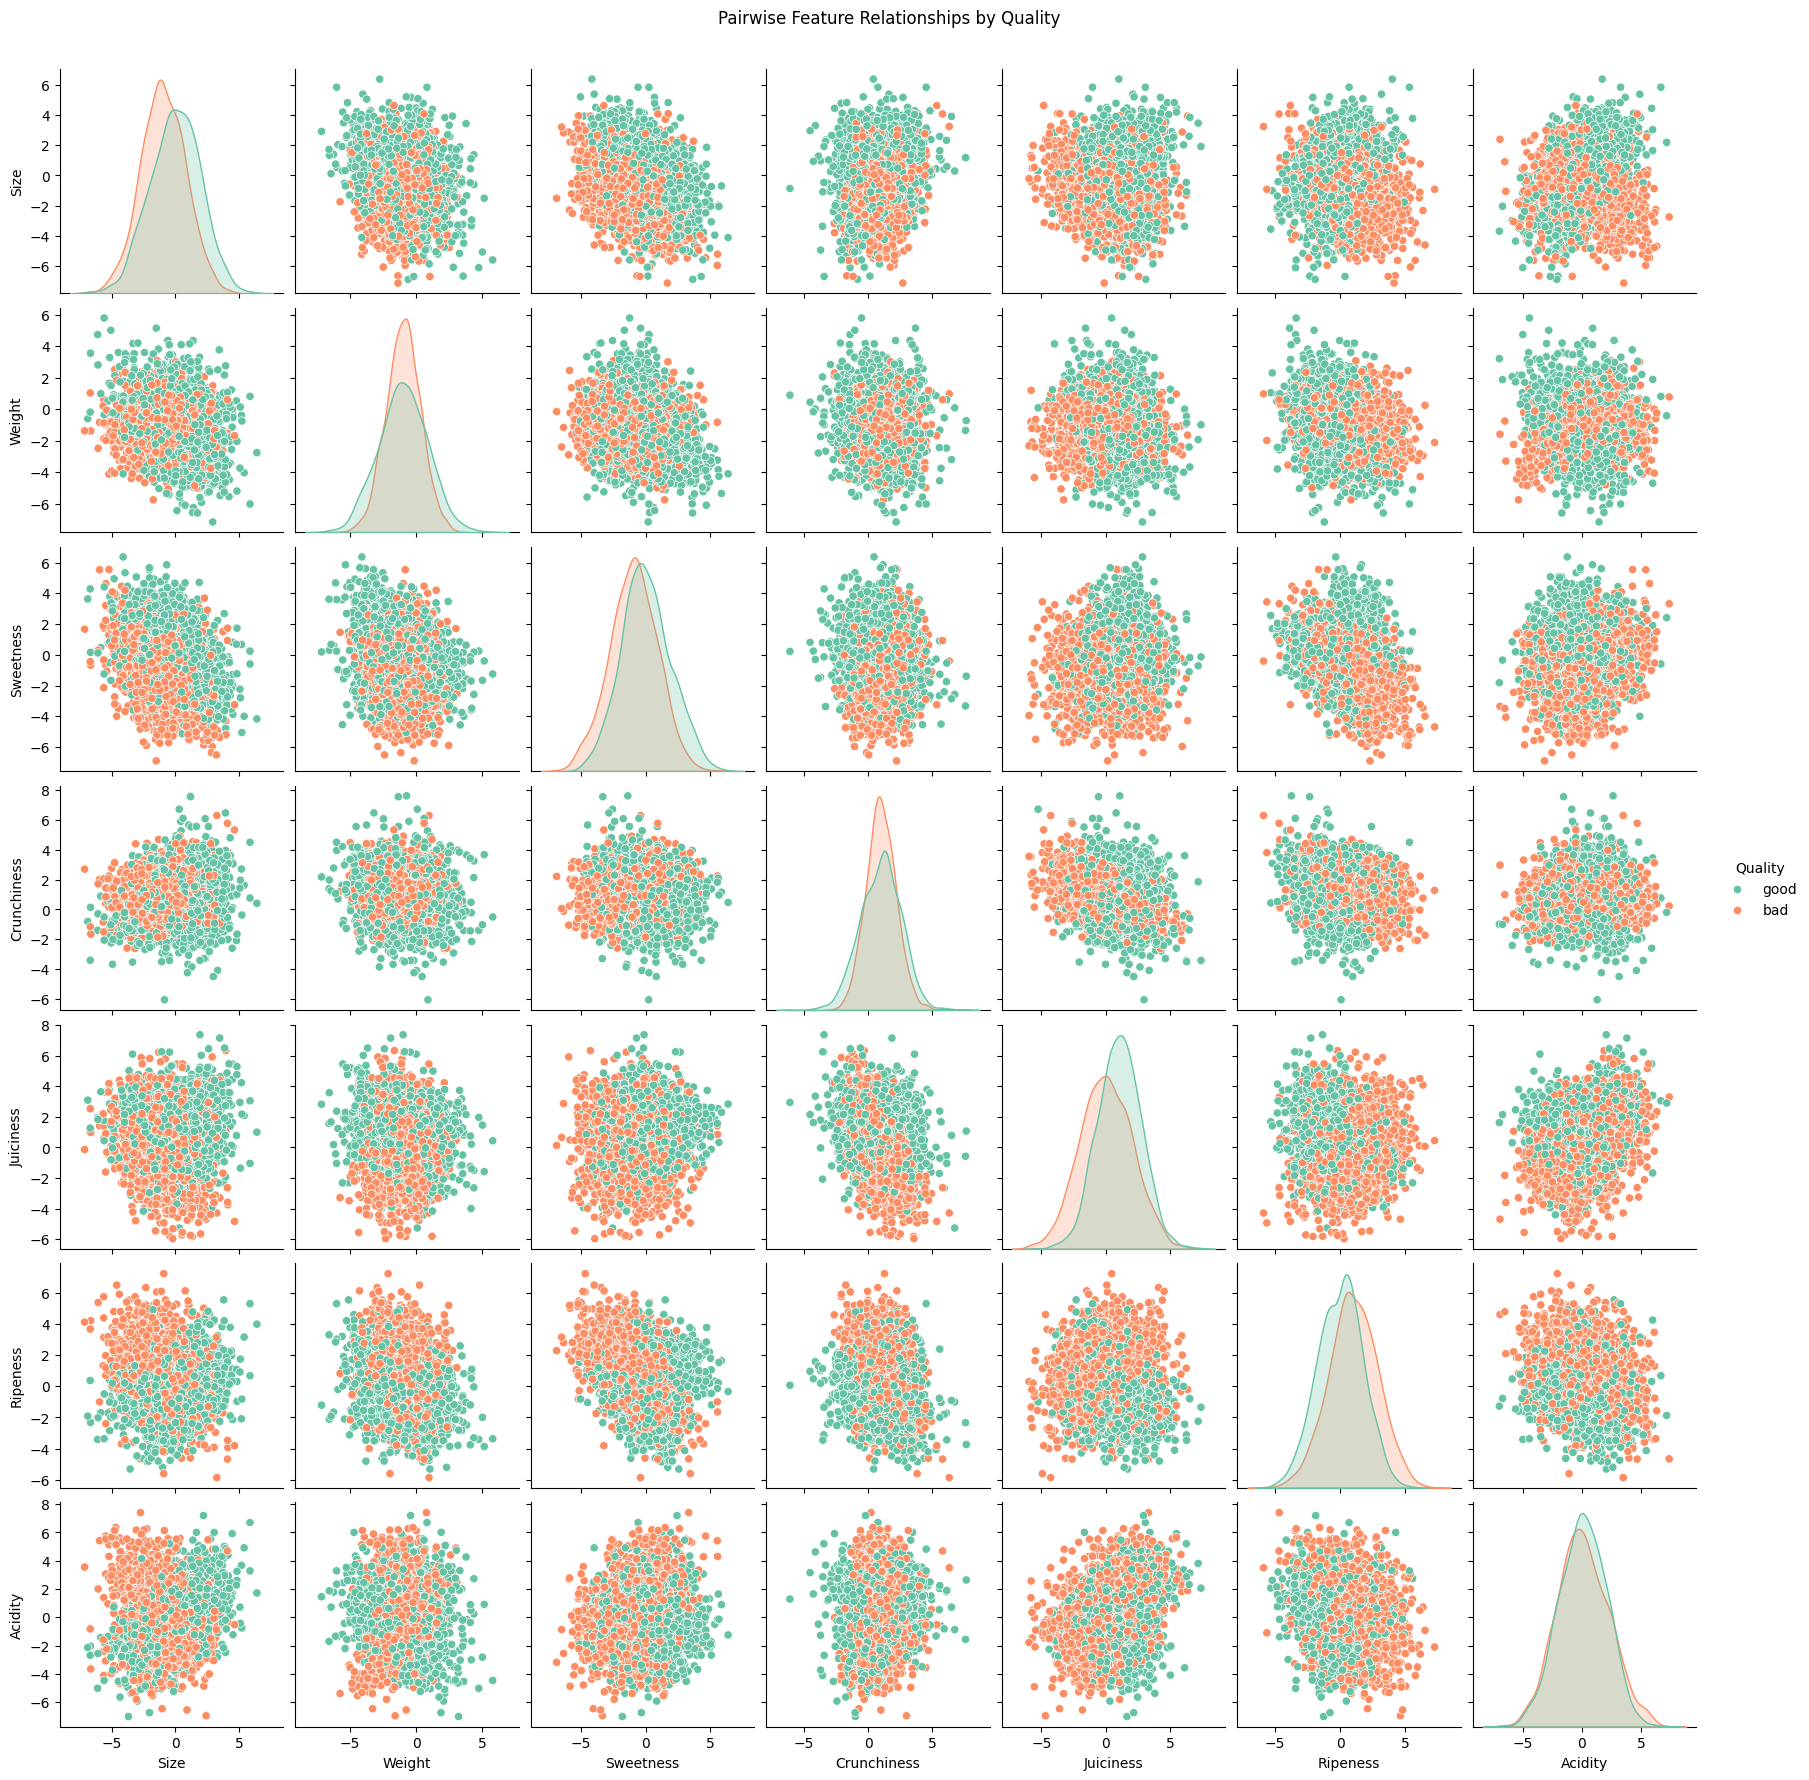

In [13]:
sns.pairplot(df, hue='Quality', diag_kind='kde', palette='Set2')
plt.suptitle("Pairwise Feature Relationships by Quality", y=1.02)
plt.show()

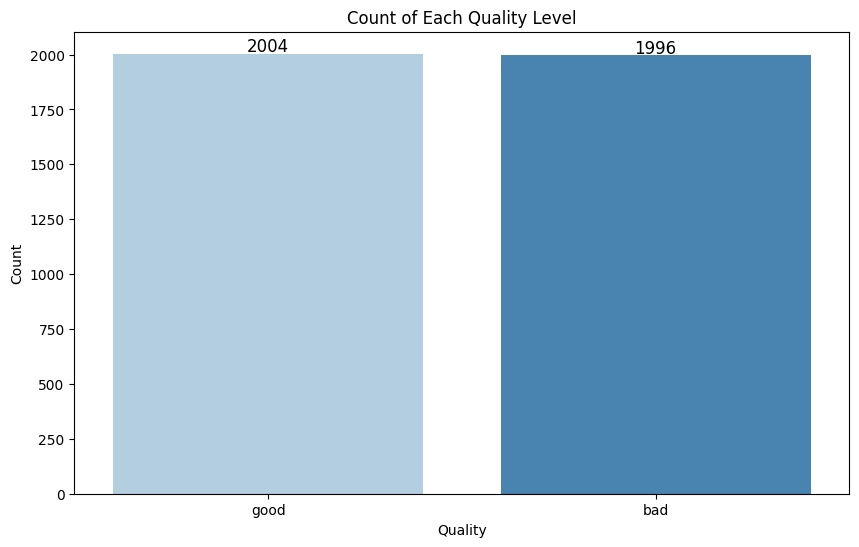

In [14]:
quality_counts = df['Quality'].value_counts()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=quality_counts.index, y=quality_counts.values, palette='Blues', hue=quality_counts.index, legend=False)
plt.title("Count of Each Quality Level")
plt.xlabel("Quality")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=12, color='black', 
                xytext=(0, 5), textcoords='offset points')
plt.show()

## Creating the One-Hot Encode

In [15]:
df_encoded = pd.get_dummies(df, columns = ['Quality'], drop_first = False)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns.tolist()
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Rows, columns:", df_encoded.shape)
df_encoded.head()

Rows, columns: (4000, 9)


,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality_bad,Quality_good
0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590,0,1
1,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809,0,1
2,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636,1,0
3,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723,0,1
4,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984,0,1


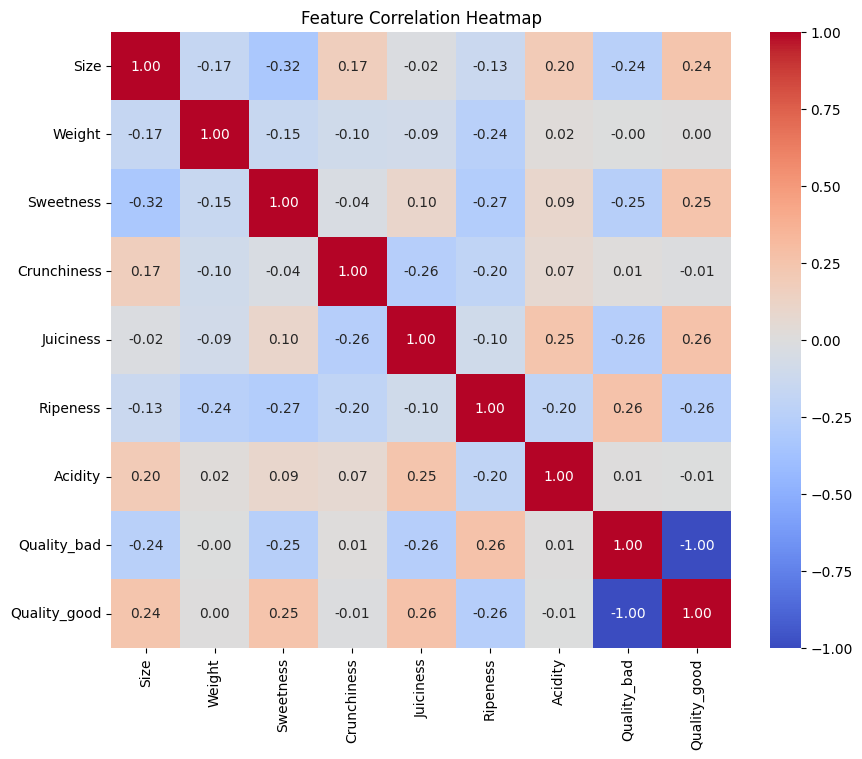

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot = True, cmap = 'coolwarm', fmt = ".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

<Axes: >

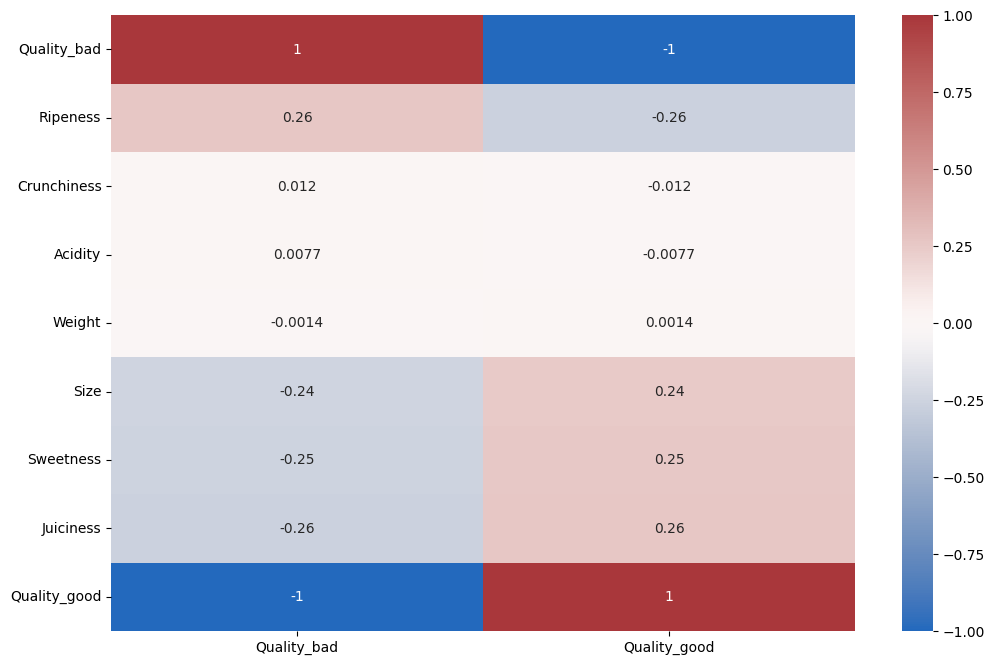

In [17]:
target_cols = ['Quality_bad', 'Quality_good']
corr_target = df_encoded.corr()[target_cols].sort_values(by=target_cols, ascending=False)

plt.figure(figsize = (12, 8))
sns.heatmap(corr_target, cbar = True, annot = True, cmap = "vlag")